<div style="background-color: black; padding: 20px; text-align: center; border-radius: 10px;">
    <h1 style="color: yellow; font-weight: bold;">
        &#8226;&#8226; 
        <span style="color: #39FF14;">  CIFAR-10 Image Classification with CNN </span> 
        &#8226;&#8226;
    </h1>
</div>

### Introduction

This project focuses on image classification using the **CIFAR-10 dataset** and a Convolutional Neural Network (CNN).

CIFAR-10 contains **60,000 color images with a resolution of 32 × 32 pixels**, distributed across 10 classes such as airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck.

The objective of this project is to build and evaluate CNN architectures for multi-class image classification. The workflow includes data preprocessing, normalization, one-hot encoding, model training, performance visualization, prediction, and model evaluation.

A deeper CNN architecture with multiple convolutional and pooling layers, together with Dropout, is used to improve feature extraction and reduce overfitting.

### Dataset Overview

| Attribute | Description |
| --- | --- |
| Dataset | CIFAR-10 |
| Total Images | 60,000 |
| Image Size | 32 × 32 pixels |
| Color Channels | RGB (3 channels) |
| Number of Classes | 10 |
| Classes | Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck |
| Training Images | 50,000 |
| Test Images | 10,000 |
| Data Format | NumPy arrays / tensors |
| Task | Multi-class image classification |

<img src='https://connectjaya.com/wp-content/uploads/2021/06/Slide7-2.jpg'>

**Import libraries**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.utils import to_categorical

In [2]:
from tensorflow.keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 72s 0us/step 


**EDA - Exploratory Data Analysis**

In [3]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((50000, 32, 32, 3), (50000, 1), (10000, 32, 32, 3), (10000, 1))

In [4]:
# Normalize image data
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Number of classes
num_classes = 10

# One-hot encode labels
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

**Modelling**

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten

In [7]:
from tensorflow.keras.layers import Input

model = Sequential()

model.add(Input(shape=(32, 32, 3)))
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

In [8]:
# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [9]:
history = model.fit(x_train, y_train, epochs=50, batch_size=32, validation_data=(x_test, y_test), verbose=2)

Epoch 1/50
1563/1563 - 12s - 8ms/step - accuracy: 0.4848 - loss: 1.4415 - val_accuracy: 0.5554 - val_loss: 1.2576
Epoch 2/50
1563/1563 - 10s - 6ms/step - accuracy: 0.5907 - loss: 1.1648 - val_accuracy: 0.5825 - val_loss: 1.1723
Epoch 3/50
1563/1563 - 10s - 6ms/step - accuracy: 0.6327 - loss: 1.0446 - val_accuracy: 0.6070 - val_loss: 1.1055
Epoch 4/50
1563/1563 - 10s - 6ms/step - accuracy: 0.6607 - loss: 0.9667 - val_accuracy: 0.6210 - val_loss: 1.0715
Epoch 5/50
1563/1563 - 10s - 6ms/step - accuracy: 0.6829 - loss: 0.9049 - val_accuracy: 0.6355 - val_loss: 1.0554
Epoch 6/50
1563/1563 - 10s - 6ms/step - accuracy: 0.7042 - loss: 0.8461 - val_accuracy: 0.6230 - val_loss: 1.1048
Epoch 7/50
1563/1563 - 10s - 6ms/step - accuracy: 0.7216 - loss: 0.7949 - val_accuracy: 0.6469 - val_loss: 1.0351
Epoch 8/50
1563/1563 - 10s - 6ms/step - accuracy: 0.7390 - loss: 0.7461 - val_accuracy: 0.6442 - val_loss: 1.0568
Epoch 9/50
1563/1563 - 10s - 6ms/step - accuracy: 0.7509 - loss: 0.7033 - val_accuracy: 

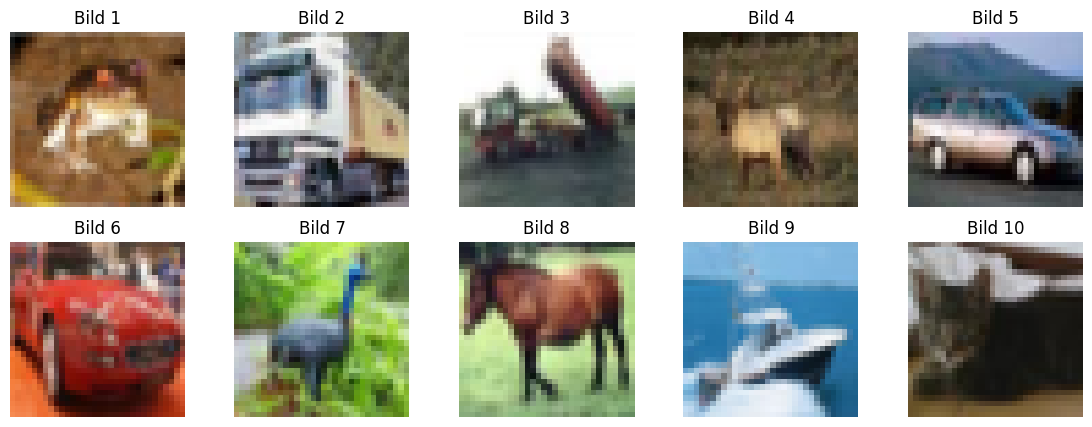

In [10]:
plt.figure(figsize=(14, 5))

# # Number of rows and columns
rows, cols = 2, 5

# Show images from index 10 to 19
for i in range(10):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(x_train[i])  # # Show the image from index 10
    plt.axis('off')  # Hide axes
    plt.title(f'Bild {i + 1}')  # Add title

plt.show()

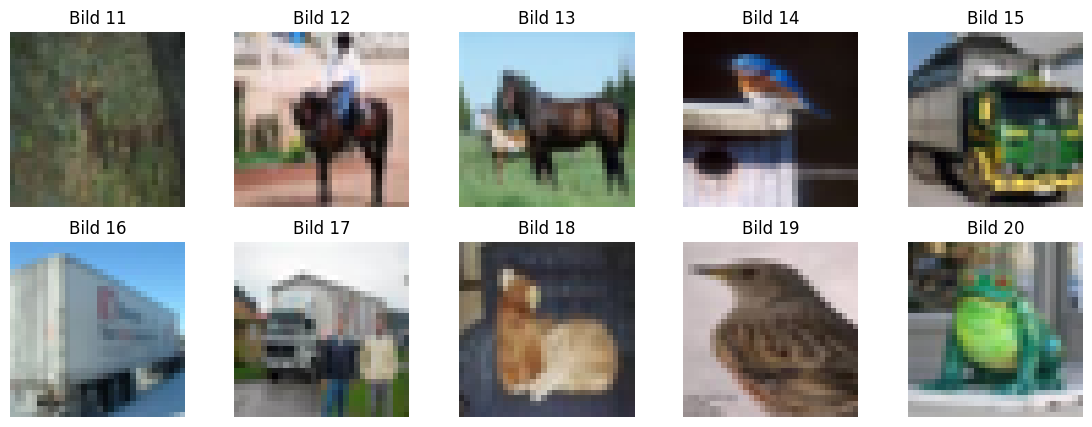

In [11]:
plt.figure(figsize=(14, 5))

rows, cols = 2, 5

for i in range(10):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(x_train[i + 10]) 
    plt.axis('off')  
    plt.title(f'Bild {i + 11}')  

plt.show()

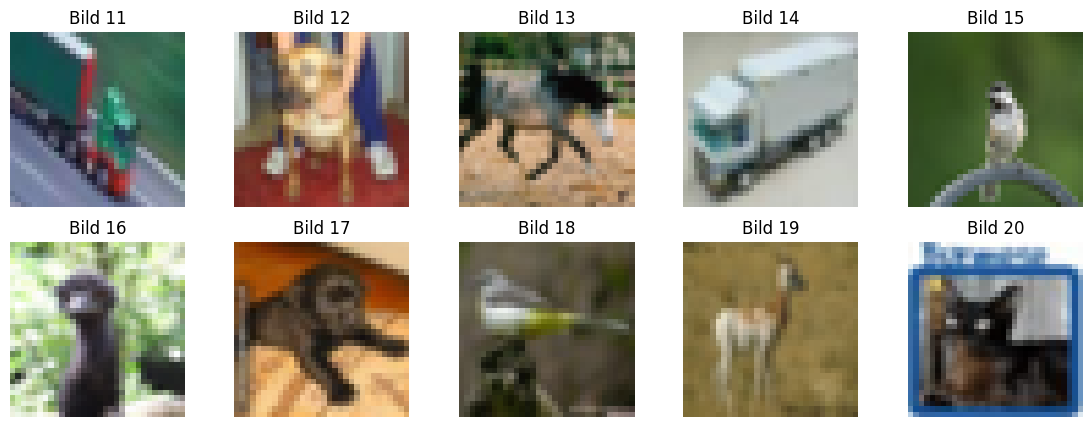

In [12]:
plt.figure(figsize=(14, 5))
77
rows, cols = 2, 5

for i in range(10):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(x_train[i + 50]) 
    plt.axis('off') 
    plt.title(f'Bild {i + 11}')  

plt.show()

>A deeper CNN architecture is used to learn increasingly complex visual features from CIFAR-10 images.
Dropout is applied to reduce overfitting, while Early Stopping automatically stops training when the validation loss no longer improves

In [13]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# CNN architecture
model = Sequential([
    Input(shape=(32, 32, 3)),

    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Stop training when validation loss no longer improves
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train the model
history = model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=2
)

Epoch 1/50
1250/1250 - 14s - 11ms/step - accuracy: 0.3692 - loss: 1.7050 - val_accuracy: 0.4592 - val_loss: 1.4765
Epoch 2/50
1250/1250 - 12s - 9ms/step - accuracy: 0.5252 - loss: 1.3242 - val_accuracy: 0.5792 - val_loss: 1.1903
Epoch 3/50
1250/1250 - 12s - 9ms/step - accuracy: 0.5878 - loss: 1.1651 - val_accuracy: 0.6301 - val_loss: 1.0551
Epoch 4/50
1250/1250 - 12s - 9ms/step - accuracy: 0.6313 - loss: 1.0575 - val_accuracy: 0.6567 - val_loss: 0.9859
Epoch 5/50
1250/1250 - 12s - 9ms/step - accuracy: 0.6589 - loss: 0.9743 - val_accuracy: 0.6702 - val_loss: 0.9600
Epoch 6/50
1250/1250 - 12s - 9ms/step - accuracy: 0.6852 - loss: 0.9031 - val_accuracy: 0.6631 - val_loss: 0.9602
Epoch 7/50
1250/1250 - 12s - 10ms/step - accuracy: 0.7050 - loss: 0.8492 - val_accuracy: 0.6967 - val_loss: 0.8899
Epoch 8/50
1250/1250 - 12s - 10ms/step - accuracy: 0.7213 - loss: 0.8000 - val_accuracy: 0.7034 - val_loss: 0.8677
Epoch 9/50
1250/1250 - 12s - 9ms/step - accuracy: 0.7385 - loss: 0.7560 - val_accurac

In [14]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 4, 4, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 2, 2, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 480,608 (1.83 MB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 320,406 (1.22 MB)

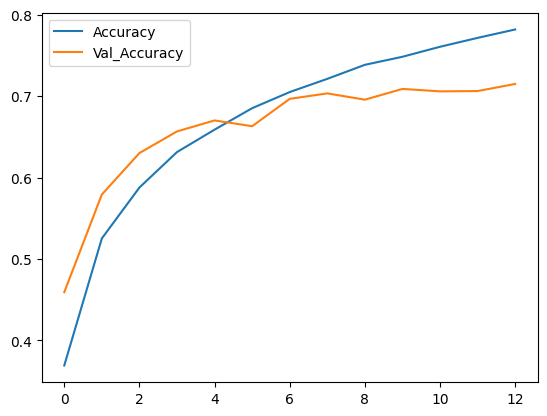

In [15]:
# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Val_Accuracy')
plt.legend();

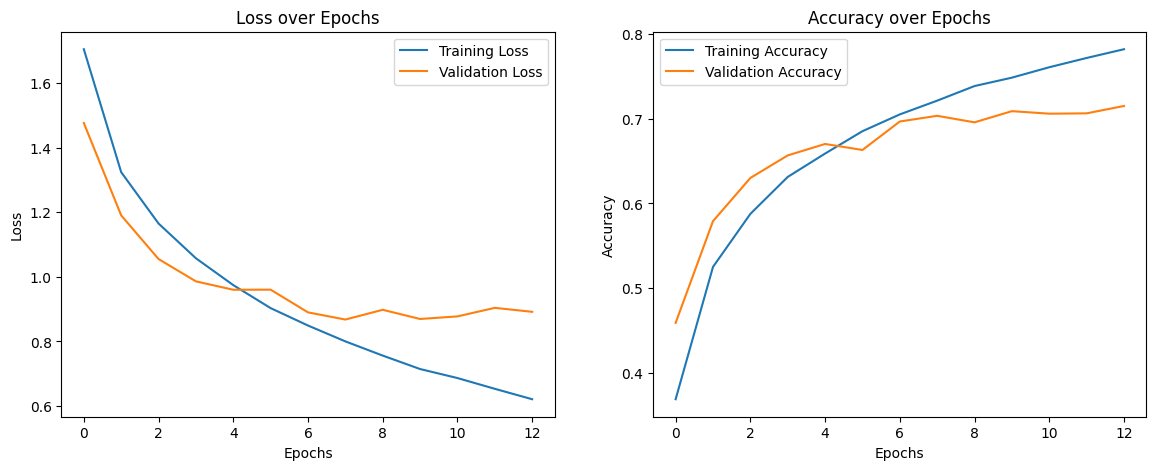

In [16]:
# Plot training results
import matplotlib.pyplot as plt

# Verlust plotten
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Genauigkeit plotten
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [17]:
model.save('cifar10_model.keras')

In [18]:
loaded_model = tf.keras.models.load_model('cifar10_model.keras')

In [19]:
class_names = [
    'Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
    'Dog', 'Frog', 'Horse', 'Ship', 'Truck'
]

In [21]:
# Prediction with the loaded model
sample_image = x_test[2].reshape(1, 32, 32, 3)

prediction = loaded_model.predict(sample_image)
predicted_class = np.argmax(prediction)

print(f"Predicted Class: {class_names[predicted_class]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Predicted Class: Ship


In [22]:
# Evaluate the loaded model
loss, accuracy = loaded_model.evaluate(x_test, y_test, verbose=0)
print(f'Loss: {loss}, Accuracy: {accuracy}')

Loss: 0.8658784031867981, Accuracy: 0.7041000127792358


## Conclusion

This project demonstrates multi-class image classification on the **CIFAR-10 dataset** using a Convolutional Neural Network (CNN).

A deeper CNN architecture with multiple convolutional and pooling layers was used to learn increasingly complex visual features. **Dropout** was applied to reduce overfitting, while **Early Stopping** was used to stop training when the validation loss stopped improving.

The training process stopped after **13 epochs**, and the final model achieved:

- **Test Accuracy:** 70.41%
- **Test Loss:** 0.8659

The results show that the CNN successfully learned meaningful visual patterns from the CIFAR-10 images, while the validation and test performance also indicate room for further improvement through techniques such as data augmentation or additional model optimization.

Overall, the project demonstrates a complete deep learning workflow including data preprocessing, CNN modeling, training, validation, performance visualization, prediction, evaluation, and model saving.